# Water Quality Classification Project

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from keras.layers import Dense, Input
from keras.losses import BinaryCrossentropy
from keras.models import Sequential
from keras.optimizers import Adam
from keras.utils import clear_session
from keras.utils import set_random_seed
from keras import initializers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import f1_score
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTENC
from sklearn.svm import SVC



## Exploratory Data Analysis

In [2]:
water_data = pd.read_csv('SAFER_RA_cleaned.csv')

# List of columns to include
include_cols = ['TINWSYS_IS_NUMBER', 'CURRENT_FAILING', 'SERVICE_CONNECTIONS', 'POPULATION', 
                'OWNER_TYPE', 'FEDERAL_CLASSIFICATION_TYPE', 'MHI', 'CALENVIRO_SCREEN_SCORE', 
                'REGIONAL_BOARD', 'FUNDING_RECEIVED_SINCE_2017', 
                'TECHNICAL_ASSISTANCE_FUNDING_SINCE_2017'
                ]

water_data_include = water_data[include_cols]

# Check for missing values
water_data_include.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3204 entries, 0 to 3203
Data columns (total 11 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   TINWSYS_IS_NUMBER                        3204 non-null   int64  
 1   CURRENT_FAILING                          3204 non-null   object 
 2   SERVICE_CONNECTIONS                      3204 non-null   int64  
 3   POPULATION                               3204 non-null   int64  
 4   OWNER_TYPE                               3204 non-null   object 
 5   FEDERAL_CLASSIFICATION_TYPE              3204 non-null   object 
 6   MHI                                      3189 non-null   float64
 7   CALENVIRO_SCREEN_SCORE                   3168 non-null   float64
 8   REGIONAL_BOARD                           3161 non-null   object 
 9   FUNDING_RECEIVED_SINCE_2017              3204 non-null   float64
 10  TECHNICAL_ASSISTANCE_FUNDING_SINCE_2017  3204 no

In [3]:
# Drop missing values
water_data_clean = water_data_include.dropna().reset_index(drop=True)

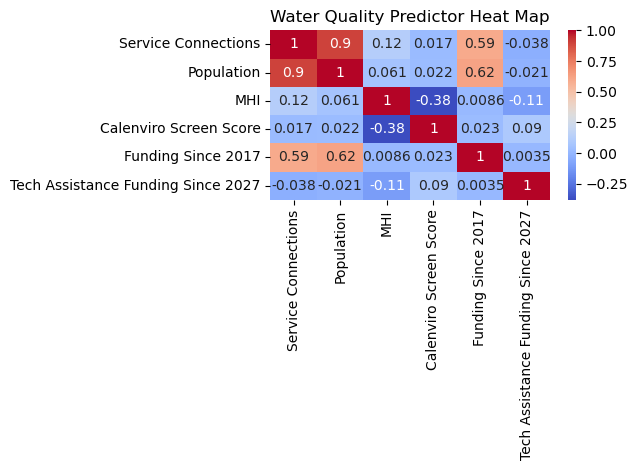

In [4]:
# Identify colinearity between continuous variables
water_cont = water_data_clean[['SERVICE_CONNECTIONS', 'POPULATION', 'MHI', 
                           'CALENVIRO_SCREEN_SCORE', 'FUNDING_RECEIVED_SINCE_2017', 
                           'TECHNICAL_ASSISTANCE_FUNDING_SINCE_2017']]

heatmap_labels = ['Service Connections', 'Population', 'MHI', 'Calenviro Screen Score', 
                  'Funding Since 2017', 'Tech Assistance Funding Since 2027']

# Heat map
sns.heatmap(water_cont.corr(), annot=True, cmap='coolwarm', 
            xticklabels=heatmap_labels, yticklabels=heatmap_labels
            ).set_title("Water Quality Predictor Heat Map")

plt.tight_layout()

Since SERVICE_CONNECTIONS and POPULATION are strongly correlated, we dropped SERVICE_CONNECTIONS from our predictors.

## Preprocessing

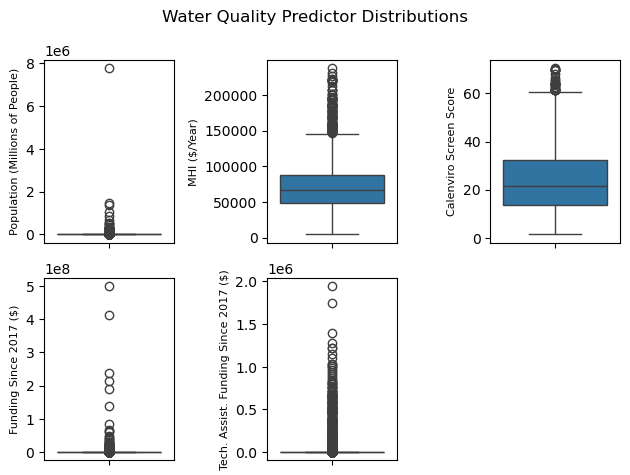

In [5]:
# Plot distributions
fig, axs =  plt.subplots(2,3)

sns.boxplot(water_cont.POPULATION,ax=axs[0,0])
axs[0,0].set_ylabel("Population (Millions of People)",fontsize='8')
sns.boxplot(water_cont.MHI,ax=axs[0,1])
axs[0,1].set_ylabel("MHI ($/Year)",fontsize='8')
sns.boxplot(water_cont.CALENVIRO_SCREEN_SCORE,ax=axs[0,2])
axs[0,2].set_ylabel("Calenviro Screen Score",fontsize='8')
sns.boxplot(water_cont.FUNDING_RECEIVED_SINCE_2017,ax=axs[1,0])
axs[1,0].set_ylabel("Funding Since 2017 ($)",fontsize='8')
sns.boxplot(water_cont.TECHNICAL_ASSISTANCE_FUNDING_SINCE_2017,ax=axs[1,1])
axs[1,1].set_ylabel("Tech. Assist. Funding Since 2017 ($)",fontsize='8')

axs[1,2].set_visible(False)
plt.suptitle("Water Quality Predictor Distributions")
plt.tight_layout()

The boxplots show that the distributions of all the continuous predictors are extremely right-skewed and on different scales. We will log-transform the data to reduce the right skew and then standardize it to fix the scale differences.

In [6]:
# Log transform
water_cont_log = water_cont.copy()
water_cont_log.POPULATION = np.log(water_cont.POPULATION + 0.1)
water_cont_log.FUNDING_RECEIVED_SINCE_2017 = np.log(
    water_cont.FUNDING_RECEIVED_SINCE_2017 + 0.1)
water_cont_log.TECHNICAL_ASSISTANCE_FUNDING_SINCE_2017 = np.log(
    water_cont.TECHNICAL_ASSISTANCE_FUNDING_SINCE_2017 + 0.1)

# Standardize
scaler = StandardScaler()
water_cont_scaled = scaler.fit_transform(water_cont_log)

water_cont_scaled = pd.DataFrame(
    scaler.fit_transform(water_cont_log),
    columns=water_cont.columns,
    index=water_cont.index)

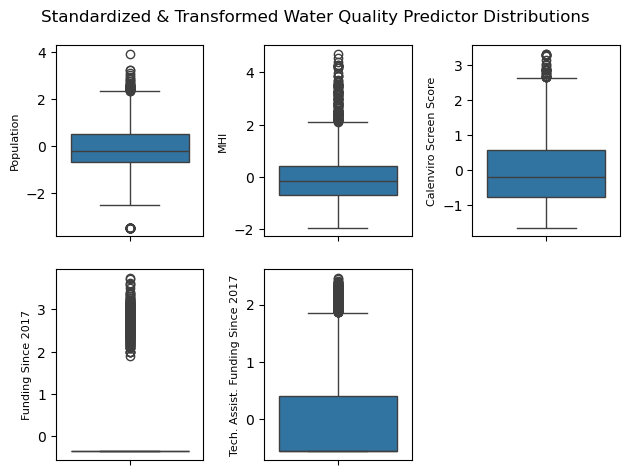

In [7]:
# Plot new distributions
fig, axs =  plt.subplots(2,3)
sns.boxplot(water_cont_scaled.POPULATION,ax=axs[0,0])
axs[0,0].set_ylabel("Population",fontsize='8')
sns.boxplot(water_cont_scaled.MHI,ax=axs[0,1])
axs[0,1].set_ylabel("MHI",fontsize='8')
sns.boxplot(water_cont_scaled.CALENVIRO_SCREEN_SCORE,ax=axs[0,2])
axs[0,2].set_ylabel("Calenviro Screen Score",fontsize='8')
sns.boxplot(water_cont_scaled.FUNDING_RECEIVED_SINCE_2017,ax=axs[1,0])
axs[1,0].set_ylabel("Funding Since 2017",fontsize='8')
sns.boxplot(water_cont_scaled.TECHNICAL_ASSISTANCE_FUNDING_SINCE_2017,ax=axs[1,1])
axs[1,1].set_ylabel("Tech. Assist. Funding Since 2017",fontsize='8')

axs[1,2].set_visible(False)
plt.suptitle("Standardized & Transformed Water Quality Predictor Distributions")
plt.tight_layout(h_pad=2)

In [8]:
# One-hot encode regional board, owner type, federal classification, and current failing
water_one_hot = pd.get_dummies(water_data_clean, 
                               columns=['CURRENT_FAILING', 'REGIONAL_BOARD', 'OWNER_TYPE', 
                                        'FEDERAL_CLASSIFICATION_TYPE'], 
                                        dtype=int)



water_one_hot.columns = ['ID','SERVICE_CONNECTIONS','POPULATION','MHI','CALENVIRO_SCREEN_SCORE',
                         'FUNDING__SINCE_2017','TECH_FUNDING_SINCE_2017','CURRENT_FAILING',
                         'CURRENT_NOT_FAILING','REGIONAL_BOARD_1','REGIONAL_BOARD_2',
                         'REGIONAL_BOARD_3','REGIONAL_BOARD_4','REGIONAL_BOARD_5_FRESNO',
                         'REGIONAL_BOARD_5_REDDING','REGIONAL_BOARD_5_SACRAMENTO',
                         'REGIONAL_BOARD_6_TAHOE','REGIONAL_BOARD_6_VICTORVILLE',
                         'REGIONAL_BOARD_7','REGIONAL_BOARD_8','REGIONAL_BOARD_9',
                         'FEDERAL_GOVERNMENT_OWNED','LOCAL_OWNED','MIXED_OWNED','PRIVATE_OWNED',
                         'STATE_GOVERNMENT_OWNED','FEDERAL_CLASS_COMMUNITY',
                         'FEDERAL_CLASS_NON-TRANSIENT_NON-COMMUNITY',
                         'FEDERAL_CLASS_TRANSIENT_NON-COMMUNITY']

In [9]:
water_one_hot

,ID,SERVICE_CONNECTIONS,POPULATION,MHI,CALENVIRO_SCREEN_SCORE,FUNDING__SINCE_2017,TECH_FUNDING_SINCE_2017,CURRENT_FAILING,CURRENT_NOT_FAILING,REGIONAL_BOARD_1,...,REGIONAL_BOARD_8,REGIONAL_BOARD_9,FEDERAL_GOVERNMENT_OWNED,LOCAL_OWNED,MIXED_OWNED,PRIVATE_OWNED,STATE_GOVERNMENT_OWNED,FEDERAL_CLASS_COMMUNITY,FEDERAL_CLASS_NON-TRANSIENT_NON-COMMUNITY,FEDERAL_CLASS_TRANSIENT_NON-COMMUNITY
0,3,19,50,130464.0,13.969586,0.0,0.00,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,4,191,459,61897.0,31.384971,0.0,0.00,0,1,0,...,0,0,0,0,0,1,0,1,0,0
2,18,207,524,178706.0,10.074452,3000000.0,830.93,0,1,0,...,0,0,0,1,0,0,0,1,0,0
3,19,1,50,140487.0,16.381997,274408.0,0.00,0,1,0,...,0,0,0,1,0,0,0,0,1,0
4,29,86959,344000,157713.0,21.844306,0.0,0.00,0,1,0,...,0,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3131,6226,4434,16595,80115.0,28.036047,0.0,169681.22,0,1,0,...,0,0,0,1,0,0,0,1,0,0
3132,6227,1270,4124,74287.0,21.614898,0.0,0.00,0,1,0,...,0,0,0,1,0,0,0,1,0,0
3133,6228,43,122,63664.0,30.214329,0.0,0.00,0,1,0,...,0,0,0,1,0,0,0,1,0,0
3134,6229,795,2772,32000.0,12.323297,443426.0,0.00,0,1,0,...,0,0,0,1,0,0,0,1,0,0


In [10]:
# Combine preprocessed categorical and continuous data
water_cat = water_one_hot.drop(['SERVICE_CONNECTIONS','POPULATION',
                                'MHI','CALENVIRO_SCREEN_SCORE',
                                'FUNDING__SINCE_2017',
                                'TECH_FUNDING_SINCE_2017'], axis=1)

# Final cleaned and pre-processed data
water_processed = pd.concat([water_cat, water_cont_scaled], axis=1)

Text(0.5, 1.0, 'PCA Plot')

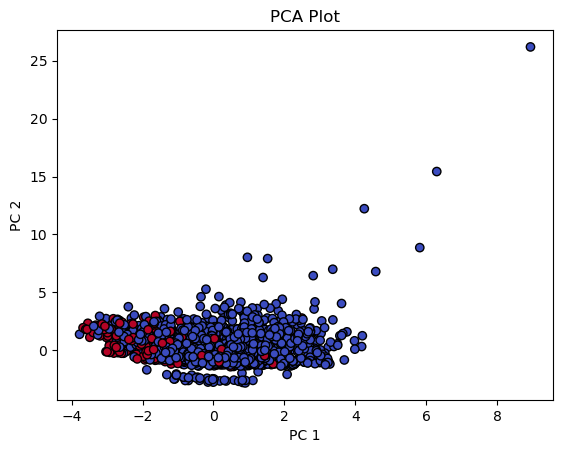

In [11]:
pca = PCA(n_components=2)
pca_data = pd.DataFrame(pca.fit_transform(X=water_cont_scaled))
colors = list(water_cat['CURRENT_FAILING'])

plt.scatter(pca_data.iloc[:,0], pca_data.iloc[:,1], c=colors, cmap='coolwarm', edgecolors='black')
plt.ylabel('PC 2')
plt.xlabel('PC 1')
plt.title('PCA Plot')



In [12]:
# Find number of observations currently failing and number not currently failing
print(f"Currently failing: {sum(colors)}") 
print(f"Currently not failing: {len(colors)}")

Currently failing: 422
Currently not failing: 3136


In [13]:
# Drop outlier
out_index = pca_data.index[pca_data.iloc[:,1] == pca_data.iloc[:,1].max()]
out_index = out_index[0]

water_processed.drop(out_index, inplace=True)
water_cat.drop(out_index, inplace=True)
water_cont_scaled.drop(out_index, inplace=True)
pca_data.drop(out_index, inplace=True)

# Model Selection

In [14]:
set_random_seed(19)

In [15]:
x_train, x_test, y_train, y_test = train_test_split(water_processed.iloc[:,3:],
                                                    water_processed.iloc[:,2],
                                                    train_size=0.9,
                                                    random_state=19)

In [ ]:
epochs = [100, 200, 300, 400, 500]
learning_rates = [0.005, 0.01, 0.05, 0.1]

# for i in epochs:
#     for j in learning_rates:
        
#         model = Sequential([
#         Input(shape=(26,)),
#         Dense(17, activation='relu', kernel_initializer=initializers.GlorotUniform(seed=19),
#         bias_initializer=initializers.Zeros()),
#         Dense(11, activation='relu', kernel_initializer=initializers.GlorotUniform(seed=19),
#         bias_initializer=initializers.Zeros()),
#         Dense(7, activation='relu', kernel_initializer=initializers.GlorotUniform(seed=19),
#         bias_initializer=initializers.Zeros()),
#         Dense(1, activation='sigmoid', kernel_initializer=initializers.GlorotUniform(seed=19),
#         bias_initializer=initializers.Zeros())])

#         optimizer = Adam(learning_rate=j)
#         model.compile(optimizer=optimizer, loss=BinaryCrossentropy(from_logits=False))
#         model.fit(x_train, y_train, epochs=i, validation_data=(x_test, y_test))
#         model_pred = model.predict(x_test)
#         model_pred_bool = model_pred > 0.5
#         model_pred_int = model_pred_bool.astype(int)
#         f1 = f1_score(y_test, model_pred_int)
#         loss.append(f1)
#         clear_session()
        

Epoch 1/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4246 - val_loss: 0.3489
Epoch 2/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 693us/step - loss: 0.3149 - val_loss: 0.3300
Epoch 3/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 684us/step - loss: 0.3017 - val_loss: 0.3225
Epoch 4/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 698us/step - loss: 0.2920 - val_loss: 0.3173
Epoch 5/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 711us/step - loss: 0.2843 - val_loss: 0.3126
Epoch 6/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 702us/step - loss: 0.2784 - val_loss: 0.3075
Epoch 7/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 672us/step - loss: 0.2739 - val_loss: 0.3081
Epoch 8/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 703us/step - loss: 0.2700 - val_loss: 0.3031
Epoch 9/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 714us/step - loss: 0.2663 - val_loss: 0.3046
Epoch 10/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 681us/step - loss: 0.2628 - val_loss: 0.3058
Epoch 11/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 692us/step - loss: 0.2602 - val_loss: 0.3039
Epoch 12/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [61]:
# Get saved tuning results
tuning = pd.read_csv('nn_tuning_metrics').drop(['Unnamed: 0'], axis=1)
loss = list(tuning.iloc[0,1:])
max_loss = max(loss)
index = loss.index(max_loss)

print(f"The maxinum F-1 score achieved was {max_loss} using {epochs[index//4]} epochs and ")
print(f"a learning rate of {learning_rates[index%4]}")

The maxinum F-1 score achieved was 0.9349736379613356 using 500 epochs and 
a learning rate of 0.01


In [ ]:
# Final Model
epoch = 500
learning_rate = 0.01
optimizer = Adam(learning_rate=learning_rate)

final_model = Sequential([
    Input(shape=(26,)),
    Dense(17, activation='relu', kernel_initializer=initializers.GlorotUniform(seed=19),
        bias_initializer=initializers.Zeros()),
    Dense(11, activation='relu', kernel_initializer=initializers.GlorotUniform(seed=19),
        bias_initializer=initializers.Zeros()),
    Dense(7, activation='relu', kernel_initializer=initializers.GlorotUniform(seed=19),
        bias_initializer=initializers.Zeros()),
    Dense(1, activation='sigmoid', kernel_initializer=initializers.GlorotUniform(seed=19),
        bias_initializer=initializers.Zeros())])


final_model.compile(optimizer=optimizer, loss=BinaryCrossentropy(from_logits=False))
final_model.fit(x_train, y_train, epochs=epoch, validation_data=(x_test, y_test))

y_pred = final_model.predict(x_test)

Epoch 1/400
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3609 - val_loss: 0.3279
Epoch 2/400
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 678us/step - loss: 0.3251 - val_loss: 0.3260
Epoch 3/400
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 683us/step - loss: 0.3120 - val_loss: 0.3175
Epoch 4/400
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 683us/step - loss: 0.3036 - val_loss: 0.3111
Epoch 5/400
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 663us/step - loss: 0.3017 - val_loss: 0.3137
Epoch 6/400
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 677us/step - loss: 0.2936 - val_loss: 0.3147
Epoch 7/400
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 672us/step - loss: 0.2909 - val_loss: 0.3108
Epoch 8/400
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 676us/step - loss: 0.2964 - val_loss: 0.3101
Epoch 9/400
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 668us/step - loss: 0.2930 - val_loss: 0.3185
Epoch 10/400
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 664us/step - loss: 0.2857 - val_loss: 0.3137
Epoch 11/400
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 673us/step - loss: 0.2895 - val_loss: 0.2967
Epoch 12/400
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [60]:
# Convert probabilities
y_pred_bool = y_pred > 0.5

y_pred_int = y_pred_bool.astype(int)

print(classification_report(y_test, y_pred_int))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00        45
           1       0.86      1.00      0.92       269

    accuracy                           0.86       314
   macro avg       0.43      0.50      0.46       314
weighted avg       0.73      0.86      0.79       314



/opt/miniconda3/envs/ds-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/ds-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/ds-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

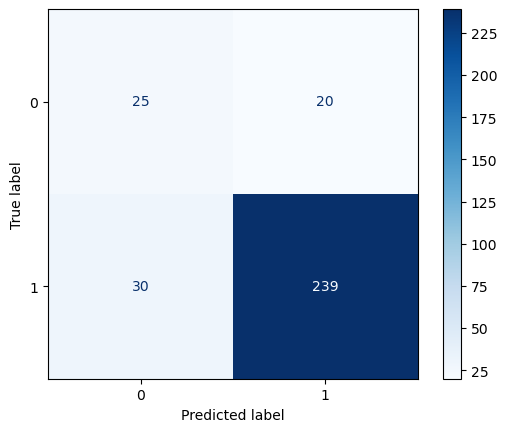

In [19]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_int, cmap='Blues')

In [20]:
# Check overfitting
y_pred_train = final_model.predict(x_train)
# Convert probabilities
y_pred_train_bool = y_pred_train > 0.5

y_pred_train_int = y_pred_train_bool.astype(int)
print(classification_report(y_train, y_pred_train_int))


89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 333us/step
              precision    recall  f1-score   support

           0       0.75      0.84      0.79       377
           1       0.97      0.96      0.97      2444

    accuracy                           0.94      2821
   macro avg       0.86      0.90      0.88      2821
weighted avg       0.94      0.94      0.94      2821



# Resampling Model

In [21]:
# Do smote
smotenc = SMOTENC(list(range(0,20)))
x_train_smotenc, y_train_smotenc = smotenc.fit_resample(x_train,y_train)


In [ ]:
# Resampled Model
epoch = 500
learning_rate = 0.01
optimizer = Adam(learning_rate=learning_rate)

smote_model = Sequential([
    Input(shape=(26,)),
    Dense(17, activation='relu', kernel_initializer=initializers.GlorotUniform(seed=19),
        bias_initializer=initializers.Zeros()),
    Dense(11, activation='relu', kernel_initializer=initializers.GlorotUniform(seed=19),
        bias_initializer=initializers.Zeros()),
    Dense(7, activation='relu', kernel_initializer=initializers.GlorotUniform(seed=19),
        bias_initializer=initializers.Zeros()),
    Dense(1, activation='sigmoid', kernel_initializer=initializers.GlorotUniform(seed=19),
        bias_initializer=initializers.Zeros())])


smote_model.compile(optimizer=optimizer, loss=BinaryCrossentropy(from_logits=False))
smote_model.fit(x_train_smotenc, y_train_smotenc, epochs=epoch, validation_data=(x_test, y_test))

y_pred_smote = smote_model.predict(x_test)

Epoch 1/500
153/153 ━━━━━━━━━━━━━━━━━━━━ 1s 904us/step - loss: 0.5314 - val_loss: 0.3835
Epoch 2/500
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 520us/step - loss: 0.4215 - val_loss: 0.4093
Epoch 3/500
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 516us/step - loss: 0.3813 - val_loss: 0.4117
Epoch 4/500
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 507us/step - loss: 0.3646 - val_loss: 0.4078
Epoch 5/500
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 513us/step - loss: 0.3518 - val_loss: 0.4049
Epoch 6/500
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 516us/step - loss: 0.3416 - val_loss: 0.4049
Epoch 7/500
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 517us/step - loss: 0.3342 - val_loss: 0.4067
Epoch 8/500
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 529us/step - loss: 0.3274 - val_loss: 0.4022
Epoch 9/500
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 533us/step - loss: 0.3212 - val_loss: 0.4091
Epoch 10/500
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 522us/step - loss: 0.3153 - val_loss: 0.4162
Epoch 11/500
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 525us/step - loss: 0.3097 - val_loss: 0.4163
Epoch 12/500
153/15

In [23]:
# Convert probabilities
y_pred_bool = y_pred > 0.5

y_pred_int_smote = y_pred_bool.astype(int)

print(classification_report(y_test, y_pred_int_smote))

              precision    recall  f1-score   support

           0       0.45      0.56      0.50        45
           1       0.92      0.89      0.91       269

    accuracy                           0.84       314
   macro avg       0.69      0.72      0.70       314
weighted avg       0.86      0.84      0.85       314



# SVM

In [24]:
# SVM with rbf kernel
svm_rbf = SVC(kernel="rbf",probability=True)
svm_rbf.fit(x_train, y_train)

svm_predictions = svm_rbf.predict_proba(x_test)

svm_predictions_int = svm_rbf.predict(x_test)

# Classification report
print(classification_report(y_test, svm_predictions_int))

              precision    recall  f1-score   support

           0       0.69      0.40      0.51        45
           1       0.91      0.97      0.94       269

    accuracy                           0.89       314
   macro avg       0.80      0.69      0.72       314
weighted avg       0.88      0.89      0.88       314



In [25]:
# Training scores
svm_predictions_int_train = svm_rbf.predict(x_train)

# Classification report
print(classification_report(y_train, svm_predictions_int_train))

              precision    recall  f1-score   support

           0       0.79      0.41      0.54       377
           1       0.92      0.98      0.95      2444

    accuracy                           0.91      2821
   macro avg       0.85      0.70      0.74      2821
weighted avg       0.90      0.91      0.89      2821



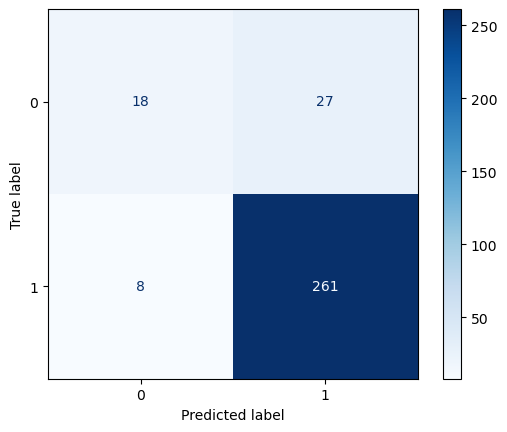

In [28]:
ConfusionMatrixDisplay.from_predictions(y_test, svm_predictions_int, cmap='Blues')

In [29]:
# SVM with weights
svm_rbf = SVC(kernel="rbf", probability=True, class_weight='balanced')
svm_rbf.fit(x_train, y_train)

svm_predictions = svm_rbf.predict_proba(x_test)

svm_predictions_int = svm_rbf.predict(x_test)

# Classification report
print(classification_report(y_test, svm_predictions_int))

              precision    recall  f1-score   support

           0       0.41      0.69      0.52        45
           1       0.94      0.84      0.89       269

    accuracy                           0.82       314
   macro avg       0.68      0.76      0.70       314
weighted avg       0.87      0.82      0.83       314

